In [1]:
import pandas as pd
import torch
from itertools import product
from IPython.display import display

from a02_functions import SimpleCNN, train_model
from a02_helper import get_raw_data, count_model_params

%load_ext autoreload
%autoreload 2

# Task 4: Exploration

In [2]:
# TODO: your code here
import matplotlib.pyplot as plt
from torch import nn

data = get_raw_data()

## Helpers

In [3]:
def compute_linear_in(channels=25, kernel_size=3, stride=2, padding=1, input_len=40):
    """Use a dummy forward pass through the conv layers to find the flattened size.
    More robust than manual math — adapts automatically if the architecture changes."""
    conv_layers = nn.Sequential(
        nn.Conv1d(1, channels, kernel_size, stride=stride, padding=padding),
        nn.ReLU(),
        nn.Conv1d(channels, channels, kernel_size, stride=stride, padding=padding),
        nn.ReLU(),
        nn.MaxPool1d(2, 2),
        nn.Conv1d(channels, channels, kernel_size, stride=stride, padding=padding),
        nn.ReLU(),
        nn.Conv1d(channels, channels, kernel_size, stride=stride, padding=padding),
        nn.ReLU(),
        nn.MaxPool1d(2, 2),
    )
    with torch.no_grad():
        dummy = torch.zeros(1, 1, input_len)
        out = conv_layers(dummy)
    return out.flatten(start_dim=1).shape[1]


def run_experiment(label, subtask, model_kw, train_kw, data):
    """Train SimpleCNN with given hyperparameters and return metrics."""
    defaults = dict(channels=25, kernel_size=3, stride=2, padding=1)
    hp = {**defaults, **model_kw}
    hp["linear_in"] = compute_linear_in(
        channels=hp["channels"], kernel_size=hp["kernel_size"],
        stride=hp["stride"], padding=hp["padding"],
    )
    # Seed before both model init AND DataLoader creation for fully reproducible runs
    torch.manual_seed(0)
    model = SimpleCNN(**hp)
    torch.manual_seed(0)  # re-seed so DataLoader shuffle is identical across experiments
    results = train_model(data, model, **train_kw)
    return {
        "subtask": subtask,
        "config":    label,
        "n_params":  count_model_params(model),
        "test_acc":  results["test_acc"][-1],
        "val_acc":   results["val_acc"][-1],
        "train_acc": results["train_acc"][-1],
    }

## Experiment Configurations

Each tuple: (label, subtask, model_kwargs, train_kwargs).
`✓` marks the default baseline value for easy reference.

In [4]:
configs = [
    # ── 4a: learning rate ────────────────────────────────────────────────────
    ("lr=1e-3",       "4a", {},                              {"lr": 1e-3, "epochs": 200}),
    ("lr=1e-2 ✓",     "4a", {},                              {"lr": 1e-2}),
    ("lr=1e-1",       "4a", {},                              {"lr": 1e-1}),
    # ── 4a: batch size ───────────────────────────────────────────────────────
    ("bs=16",         "4a", {},                              {"batch_size": 16}),
    ("bs=64 ✓",       "4a", {},                              {"batch_size": 64}),
    ("bs=256",        "4a", {},                              {"batch_size": 256}),
    # ── 4b: kernel size (padding adjusted to keep spatial sizes reasonable) ──
    ("k=1,p=0",       "4b", {"kernel_size": 1, "padding": 0}, {}),
    ("k=3,p=1 ✓",     "4b", {},                              {}),
    ("k=5,p=2",       "4b", {"kernel_size": 5, "padding": 2}, {}),
    # ── 4c: number of channels ───────────────────────────────────────────────
    ("ch=5",          "4c", {"channels": 5},                 {}),
    ("ch=25 ✓",       "4c", {},                              {}),
    ("ch=50",         "4c", {"channels": 50},                {}),
    # ── 4d: stride ───────────────────────────────────────────────────────────
    ("stride=1",      "4d", {"stride": 1},                   {}),
    ("stride=2 ✓",    "4d", {},                              {}),
]

## Run All Experiments

In [5]:
rows = []
for label, subtask, model_kw, train_kw in configs:
    print(f"\n{'─'*50}\n[{subtask}] {label}")
    row = run_experiment(label, subtask, model_kw, train_kw, data)
    rows.append(row)
    print(f"  test_acc={row['test_acc']:.1f}%  val_acc={row['val_acc']:.1f}%  n_params={row['n_params']}")


──────────────────────────────────────────────────
[4a] lr=1e-3


epoch 0, dt 1.37s, train_loss 2.144e+00, val_loss 2.109e+00, train_acc 20.7, val_acc 20.4


epoch 10, dt 5.84s, train_loss 1.213e+00, val_loss 1.257e+00, train_acc 51.9, val_acc 50.5


epoch 20, dt 5.79s, train_loss 9.965e-01, val_loss 1.109e+00, train_acc 57.8, val_acc 54.5


epoch 30, dt 5.78s, train_loss 7.504e-01, val_loss 9.992e-01, train_acc 63.2, val_acc 58.4


...

epoch 60, dt 5.99s, train_loss 1.497e-02, val_loss 5.203e-01, train_acc 99.9, val_acc 91.1


epoch 70, dt 5.90s, train_loss 8.851e-04, val_loss 5.420e-01, train_acc 100.0, val_acc 91.2


epoch 80, dt 6.01s, train_loss 2.460e-04, val_loss 5.868e-01, train_acc 100.0, val_acc 91.2


epoch 90, dt 5.92s, train_loss 2.724e-04, val_loss 6.145e-01, train_acc 100.0, val_acc 91.0


Final result: train_loss 3.191e-04, val_loss 6.145e-01, test_loss 7.175e-01, train_acc 100.0, val_acc 91.0, test_acc 91.0
  test_acc=91.0%  val_acc=91.0%  n_params=6060


## Summary Table

In [6]:
df = pd.DataFrame(rows)
display(df)

,subtask,config,n_params,test_acc,val_acc,train_acc
0,4a,lr=1e-3,6060,81.0,82.625,98.46875
1,4a,lr=1e-2 ✓,6060,91.0,91.000,100.00000
2,4a,lr=1e-1,6060,34.3,36.500,37.31250
3,4a,bs=16,6060,84.1,88.500,96.81250
4,4a,bs=64 ✓,6060,91.0,91.000,100.00000
5,4a,bs=256,6060,84.9,86.875,100.00000
6,4b,"k=1,p=0",2260,13.9,11.750,14.12500
7,4b,"k=3,p=1 ✓",6060,91.0,91.000,100.00000
8,4b,"k=5,p=2",9860,93.5,92.250,100.00000
9,4c,ch=5,320,54.4,52.000,55.84375


## Visualizations

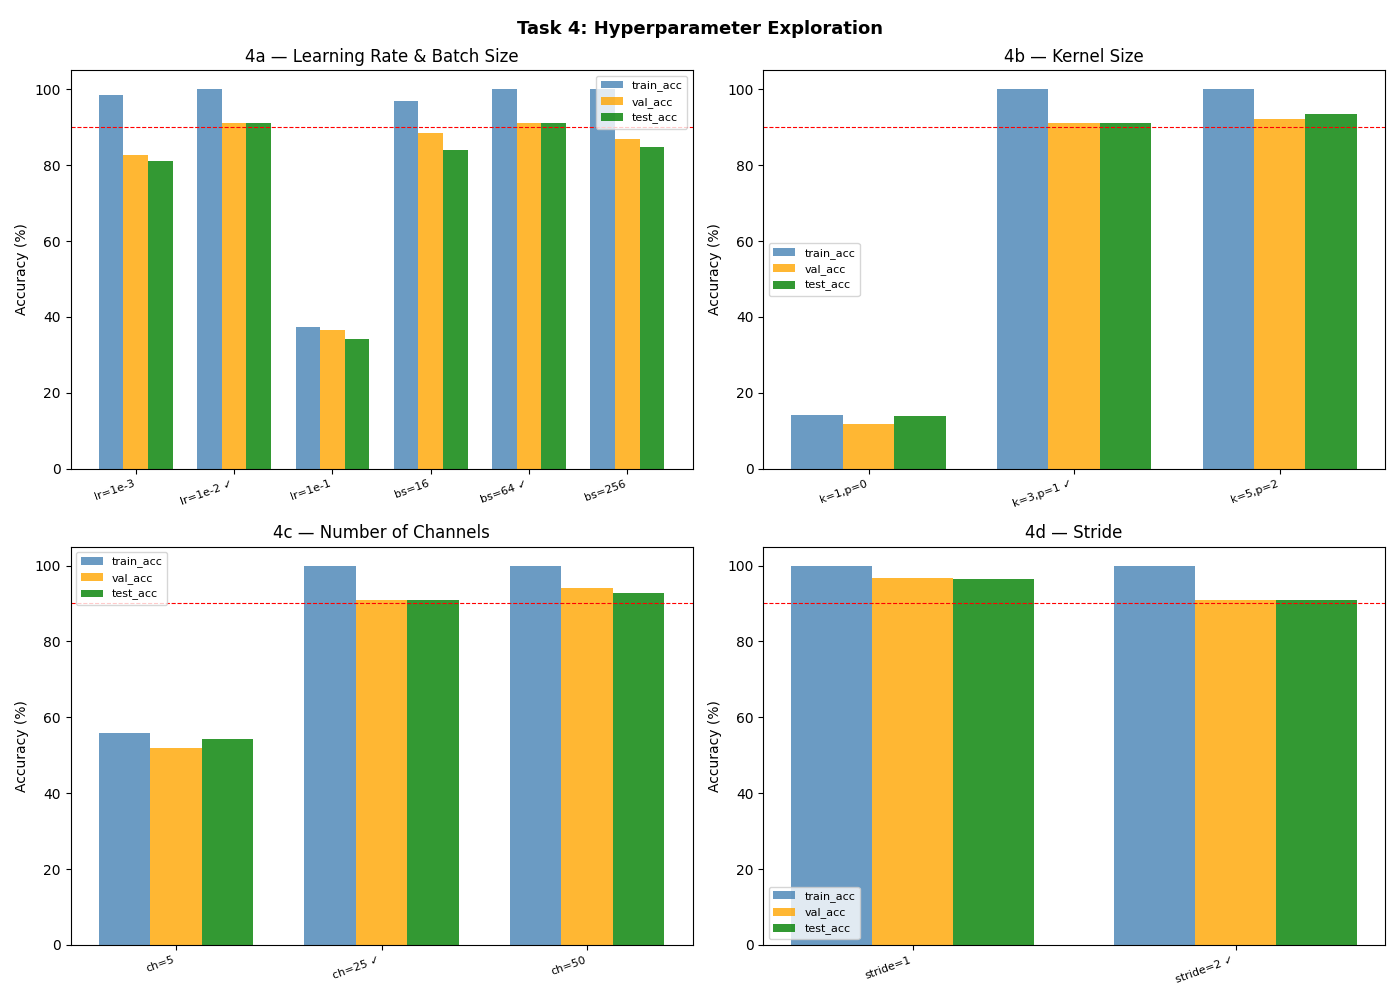

In [7]:
subtask_titles = {
    "4a": "4a — Learning Rate & Batch Size",
    "4b": "4b — Kernel Size",
    "4c": "4c — Number of Channels",
    "4d": "4d — Stride",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (st, title) in zip(axes, subtask_titles.items()):
    sub = df[df["subtask"] == st].reset_index(drop=True)
    x = range(len(sub))
    width = 0.25
    ax.bar([i - width for i in x], sub["train_acc"], width=width, label="train_acc", alpha=0.8, color="steelblue")
    ax.bar([i         for i in x], sub["val_acc"],   width=width, label="val_acc",   alpha=0.8, color="orange")
    ax.bar([i + width for i in x], sub["test_acc"],  width=width, label="test_acc",  alpha=0.8, color="green")
    ax.set_xticks(list(x))
    ax.set_xticklabels(sub["config"], rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.axhline(y=90, color="red", linestyle="--", linewidth=0.8, label="90% target")

plt.suptitle("Task 4: Hyperparameter Exploration", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

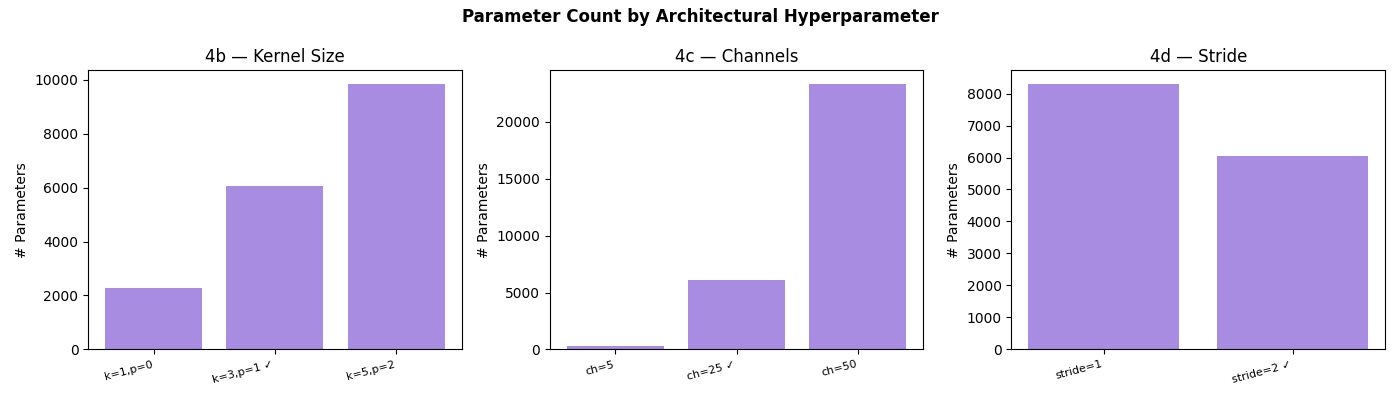

In [8]:
# Parameter count comparison (relevant for 4b, 4c, 4d)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, st, title in zip(axes, ["4b", "4c", "4d"],
                          ["4b — Kernel Size", "4c — Channels", "4d — Stride"]):
    sub = df[df["subtask"] == st].reset_index(drop=True)
    ax.bar(range(len(sub)), sub["n_params"], color="mediumpurple", alpha=0.8)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["config"], rotation=15, ha="right", fontsize=8)
    ax.set_ylabel("# Parameters")
    ax.set_title(title)

plt.suptitle("Parameter Count by Architectural Hyperparameter", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()